In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Embedding, Dense, Dropout, SpatialDropout1D,Bidirectional,GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# For preprocessing the text data
import re
from textwrap import wrap
from textblob import TextBlob
from collections import Counter
from wordsegment import load, segment
from string import punctuation
from nltk import word_tokenize, ngrams
load()  # for wordsegment

from text_cleaning import TextCleaning


In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Silence TF warnings (safe on M1)

import tensorflow as tf

# Force MPS (M1 GPU) if available — huge speedup!
if tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('GPU')[0], True)
    print("Using M1 GPU (MPS) for acceleration!")

# NO XLA or mixed precision — they cause issues on M1
# (M1 is fast enough without them via Metal)

Using M1 GPU (MPS) for acceleration!


In [3]:
## ===========================
#  1. LOAD Data
## ===========================  

X_train_raw = pd.read_csv("./data/preprocessed/X_train_GGL.csv", index_col=0)
X_test_raw = pd.read_csv("./data/preprocessed/X_test_GGL.csv", index_col=0)
y_target = pd.read_csv("./Raw_Data/Y_train.csv", index_col=0)

# Now create y_train and y_test from the y_target with proper indexing

y_inTrain = y_target.loc[X_train_raw.index]
y_inTest = y_target.loc[X_test_raw.index]

In [4]:
## ===========================
#  2. Prepare necessary dataframe
## =========================== 

df_train = X_train_raw.merge(y_inTrain, left_index=True, right_index=True)
df_train = df_train.drop('text', axis=1)
df_train['text_GGL'] = df_train['text_GGL'].str.lower()
df_train = df_train.dropna()
print(len(df_train))

df_test = X_test_raw.merge(y_inTest, left_index=True, right_index=True)
df_test = df_test.drop('text', axis=1)
df_test['text_GGL'] = df_test['text_GGL'].str.lower()
df_test = df_test.dropna()
print(len(df_test))

#df = pd.concat([df_train, df_test])
#df = df.dropna()

67681
16911


#### Some preprocessing

In [5]:
# Contraction Dictionary for the expansion
contractions_dict = {
    "ain't": "am not", "aren't": "are not", "can't": "cannot", "can't've": "cannot have", "'cause": "because",
    "could've": "could have", "couldn't": "could not", "couldn't've": "could not have", "didn't": "did not", "doesn't": "does not",
    "doesn’t": "does not", "don't": "do not", "don’t": "do not", "hadn't": "had not", "hadn't've": "had not have", "hasn't": "has not",
    "haven't": "have not", "he'd": "he had", "he'd've": "he would have", "he'll": "he will", "he'll've": "he will have", "he's": "he is",
    "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is", "i'd": "i would", "i'd've": "i would have",
    "i'll": "i will", "i'll've": "i will have", "i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would", "it'd've": "it would have",
    "it'll": "it will", "it'll've": "it will have", "it's": "it is", "let's": "let us", "ma'am": "madam", "mayn't": "may not","might've": "might have",
    "mightn't": "might not", "mightn't've": "might not have", "must've": "must have", "mustn't": "must not", "mustn't've": "must not have",
    "needn't": "need not", "needn't've": "need not have", "o'clock": "of the clock", "oughtn't": "ought not", "oughtn't've": "ought not have",
    "shan't": "shall not","sha'n't": "shall not", "shan't've": "shall not have", "she'd": "she would", "she'd've": "she would have",
    "she'll": "she will", "she'll've": "she will have", "she's": "she is", "should've": "should have", "shouldn't": "should not",
    "shouldn't've": "should not have", "so've": "so have", "so's": "so is", "that'd": "that would", "that'd've": "that would have",
    "that's": "that is", "there'd": "there would", "there'd've": "there would have", "there's": "there is", "they'd": "they would",
    "they'd've": "they would have", "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have",
    "to've": "to have", "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have",
    "we're": "we are", "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
    "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
    "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have", "why's": "why is",
    "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have", "would've": "would have",
    "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all", "y’all": "you all", "y'all'd": "you all would",
    "y'all'd've": "you all would have", "y'all're": "you all are", "y'all've": "you all have", "you'd": "you would", "you'd've": "you would have",
    "you'll": "you will", "you'll've": "you will have", "you're": "you are", "you've": "you have", "ain’t": "am not", "aren’t": "are not",
    "can’t": "cannot", "can’t’ve": "cannot have", "’cause": "because", "could’ve": "could have", "couldn’t": "could not", "couldn’t’ve": "could not have",
    "didn’t": "did not", "doesn’t": "does not", "don’t": "do not", "don’t": "do not", "hadn’t": "had not", "hadn’t’ve": "had not have",
    "hasn’t": "has not", "haven’t": "have not", "he’d": "he had", "he’d’ve": "he would have", "he’ll": "he will", "he’ll’ve": "he will have",
    "he’s": "he is", "how’d": "how did", "how’d’y": "how do you", "how’ll": "how will", "how’s": "how is", "i’d": "i would", "i’d’ve": "i would have",
    "i’ll": "i will", "i’ll’ve": "i will have", "i’m": "i am", "i’ve": "i have", "isn’t": "is not", "it’d": "it would", "it’d’ve": "it would have",
    "it’ll": "it will", "it’ll’ve": "it will have", "it’s": "it is", "let’s": "let us", "ma’am": "madam", "mayn’t": "may not",
    "might’ve": "might have", "mightn’t": "might not", "mightn’t’ve": "might not have", "must’ve": "must have", "mustn’t": "must not",
    "mustn’t’ve": "must not have", "needn’t": "need not", "needn’t’ve": "need not have", "o’clock": "of the clock",
    "oughtn’t": "ought not", "oughtn’t’ve": "ought not have", "shan’t": "shall not", "sha’n’t": "shall not", "shan’t’ve": "shall not have",
    "she’d": "she would", "she’d’ve": "she would have", "she’ll": "she will", "she’ll’ve": "she will have", "she’s": "she is",
    "should’ve": "should have", "shouldn’t": "should not", "shouldn’t’ve": "should not have", "so’ve": "so have", "so’s": "so is",
    "that’d": "that would", "that’d’ve": "that would have", "that’s": "that is", "there’d": "there would", "there’d’ve": "there would have",
    "there’s": "there is", "they’d": "they would", "they’d’ve": "they would have", "they’ll": "they will", "they’ll’ve": "they will have",
    "they’re": "they are", "they’ve": "they have", "to’ve": "to have", "wasn’t": "was not", "we’d": "we would", "we’d’ve": "we would have",
    "we’ll": "we will", "we’ll’ve": "we will have", "we’re": "we are", "we’ve": "we have", "weren’t": "were not", "what’ll": "what will",
    "what’ll’ve": "what will have", "what’re": "what are", "what’s": "what is", "what’ve": "what have", "when’s": "when is",
    "when’ve": "when have", "where’d": "where did", "where’s": "where is", "where’ve": "where have", "who’ll": "who will",
    "who’ll’ve": "who will have", "who’s": "who is", "who’ve": "who have","why’s": "why is", "why’ve": "why have", "will’ve": "will have",
    "won’t": "will not", "won’t’ve": "will not have", "would’ve": "would have", "wouldn’t": "would not", "wouldn’t’ve": "would not have",
    "y’all": "you all", "y’all": "you all", "y’all’d": "you all would", "y’all’d’ve": "you all would have", "y’all’re": "you all are",
    "y’all’ve": "you all have", "you’d": "you would", "you’d’ve": "you would have", "you’ll": "you will", "you’ll’ve": "you will have",
    "you’re": "you are", "you’re": "you are", "you’ve": "you have"
}

contractions_re = re.compile('(%s)' % '|'.join(contractions_dict.keys()))

In [6]:
# ==========================
# 3. TEXT PREPROCESSING FUNCTIONS
# ==========================

# Function expand the contractions if there's any
def expand_contractions(s, contractions_dict=contractions_dict):
    def replace(match):
        return contractions_dict[match.group(0)]
    return contractions_re.sub(replace, s)

# NEW: Split concatenated words and numbers
def split_words_and_numbers(text):
    if not isinstance(text, str):
        return text
    
    # 1. split letters + numbers both directions
    text = re.sub(r'([A-Za-z])([0-9])', r'\1 \2', text)
    text = re.sub(r'([0-9])([A-Za-z])', r'\1 \2', text)

    # 2. split glued English words (via wordsegment)
    tokens = text.split()
    result = []

    for tok in tokens:
        if tok.isalpha():  # only letters, no numbers
            seg = segment(tok)  # returns list of tokens
            result.extend(seg)
        else:
            result.append(tok)

    return " ".join(result)


# Function to preprocess the colTxts
def main_preprocessing(colTxt):
    colTxt=colTxt.copy()

    # Removing emails and URLs
    colTxt = colTxt.apply(lambda x: re.sub('\S+@\S+', '', x))

    # Removing URLs
    colTxt = colTxt.apply(lambda x:
        re.sub("((http\://|https\://|ftp\://)|(www.))+(([a-zA-Z0-9\.-]+\.[a-zA-Z]{2,4})|"
               "([0-9]{1,3}\.[0-9]{1,3}\.[0-9]{1,3}\.[0-9]{1,3}))(/[a-zA-Z0-9%:/-_\?\.'~]*)?",
               '', x)
    )

    # Mapping the contractions
    colTxt = colTxt.apply(lambda x: expand_contractions(x))

    # Stripping possessives
    colTxt = colTxt.apply(lambda x: x.replace("'s", '')
                                          .replace('’s', '')
                                          .replace("\\'s", '')
                                          .replace("\\’s", ''))
    

    # Remove extra spaces
    colTxt = colTxt.apply(lambda x: re.sub(' +', ' ', x))

    # NEW: Fix glued words + numbers
    colTxt = colTxt.apply(split_words_and_numbers)

    # Remove extra spaces again
    colTxt = colTxt.apply(lambda x: re.sub(' +', ' ', x))

    # Removing punctuation
    colTxt = colTxt.apply(lambda x: ''.join(ch for ch in x if ch not in punctuation))

    # Final cleanup
    colTxt = colTxt.apply(lambda x: re.sub(' +', ' ', x).strip())

    return colTxt


In [7]:
# ==========================
# 4.TEXT PREPROCESSING on training data!)
# ==========================

print("Preprocessing training text...")
df_train_cln = df_train.copy()
df_train_cln['processed_text'] = main_preprocessing(df_train_cln['text_GGL'])
df_train_cln['processed_text'] = df_train_cln['processed_text'].astype('str')

# Drop duplicated set
df_train_cln = df_train_cln.drop('text_GGL', axis=1)
#df_train_cln = df_train_cln.drop_duplicates(subset='processed_text', keep='first').reset_index(drop=True)
#df_train_cln.head()

Preprocessing training text...


In [8]:
print("Computing class weights to handle imbalance...")
classes = np.unique(df_train_cln['prdtypecode'])                 # all 27 original codes
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=df_train_cln['prdtypecode']                                 # original prdtypecode column
)
class_weights = dict(zip(classes, weights))

# Show how strong the correction is
print(f"Smallest class weight    : {min(class_weights.values()):.4f}")
print(f"Largest class weight     : {max(class_weights.values()):.4f}")

Computing class weights to handle imbalance...
Smallest class weight    : 0.3074
Largest class weight     : 4.1094


### Modelling

In [10]:
# ==========================
# 6. Data splitting for the model
# ==========================

# After cleaning df_train (only training data!)
print("Encoding labels on full training set...")
le = LabelEncoder()
df_train_cln['label_enc'] = le.fit_transform(df_train_cln['prdtypecode'])  # temporary column

X = df_train_cln['processed_text']
y = df_train_cln['label_enc']     

X_train, X_val, y_train_enc, y_val_enc = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y   # ← y is already encoded!
)


Encoding labels on full training set...


In [11]:
# ==========================
# 5.Tokenization & label encoding
# ==========================

texts_train = X_train.tolist()
texts_val = X_val.tolist()

# label encoding 
#le = LabelEncoder()
#y_train_enc = le.fit_transform(y_train)
#y_val_enc = le.transform(y_val)

num_classes = len(le.classes_)
print("Number of classes:", num_classes)

# --- Tokenization ---- 
max_words = 60000  #change the vocab size depending on dataset
max_sequence_length = 200  # Max length of each product description

tokenizer = Tokenizer(num_words=max_words,oov_token="<OOV>")
tokenizer.fit_on_texts(texts_train)

# Convert the text to sequences
X_train_seq = tokenizer.texts_to_sequences(texts_train)
X_val_seq = tokenizer.texts_to_sequences(texts_val)

# Pad sequences to ensure uniform length
# 5. Pad
X_train_pad = pad_sequences(X_train_seq, maxlen=max_sequence_length, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_sequence_length, padding='post', truncating='post')

Number of classes: 27


In [12]:
# ==========================
# 6. Build Model - LSTM
# ==========================

#tf.keras.mixed_precision.set_global_policy('mixed_float16')
#tf.config.optimizer.set_jit(True)

model = Sequential()
model.add(Embedding(input_dim=max_words, 
                    output_dim=300, 
                    input_length=max_sequence_length))
model.add(SpatialDropout1D(0.2))
#model.add(LSTM(128,dropout=0.3,recurrent_dropout=0.0))
model.add(Bidirectional(LSTM(128, return_sequences=True, dropout=0.3)))
model.add(Bidirectional(LSTM(64, dropout=0.4)))          # ← no pooling here!
model.add(Dropout(0.4))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))            
model.add(Dense(num_classes, activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0007),
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7),
]

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [13]:
# ==========================
# 7. Modeling - LSTM
# ==========================

history = model.fit(
    X_train_pad, y_train_enc,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_pad, y_val_enc),
    callbacks=callbacks, 
    class_weight=class_weights,
)

Epoch 1/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 297s 346ms/step - accuracy: 0.4505 - loss: 1.8195 - val_accuracy: 0.6756 - val_loss: 1.0747 - learning_rate: 7.0000e-04
Epoch 2/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 285s 337ms/step - accuracy: 0.7151 - loss: 0.9684 - val_accuracy: 0.7584 - val_loss: 0.8489 - learning_rate: 7.0000e-04
Epoch 3/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 282s 334ms/step - accuracy: 0.8039 - loss: 0.6767 - val_accuracy: 0.7685 - val_loss: 0.8276 - learning_rate: 7.0000e-04
Epoch 4/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 282s 333ms/step - accuracy: 0.8541 - loss: 0.5150 - val_accuracy: 0.7776 - val_loss: 0.8406 - learning_rate: 7.0000e-04
Epoch 5/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 279s 330ms/step - accuracy: 0.8829 - loss: 0.4168 - val_accuracy: 0.7745 - val_loss: 0.8815 - learning_rate: 7.0000e-04
Epoch 6/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 320s 379ms/step - accuracy: 0.9011 - loss: 0.3443 - val_accuracy: 0.7785 - val_loss: 0.9381 - learning_rate: 7.0000e-04
Epoch 7/50
846/846 ━━━━━━━━━━━━━━━━━━━━ 

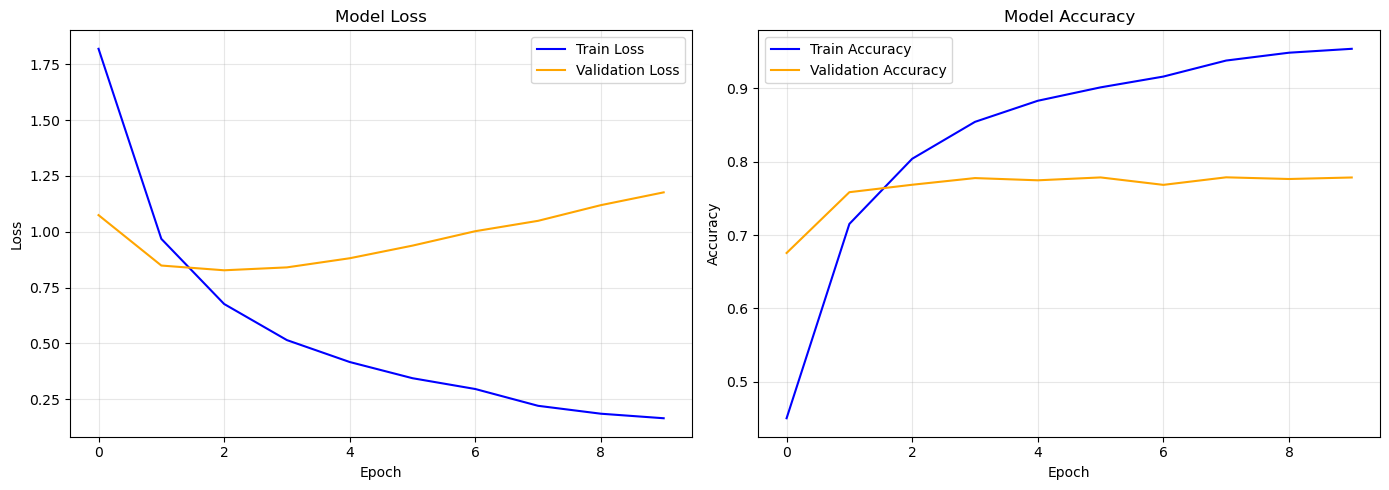

In [14]:
# ==========================
# 8. Accuracy and Loss plot
# ==========================

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(history.history['loss'], label='Train Loss', color='blue')
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Call it after training
plot_training_history(history)

#### Prediction

In [ ]:
# ==========================
# 8.TEXT PREPROCESSING on test data!)
# ==========================

print("Preprocessing test text...")
df_test_cln = df_test.copy()
df_test_cln['processed_text'] = main_preprocessing(df_test_cln['text_GGL'])
df_test_cln['processed_text'] = df_test_cln['processed_text'].astype('str')

# Drop duplicated set
df_test_cln = df_test_cln.drop('text_GGL', axis=1)
#df_test_cln = df_test_cln.drop_duplicates(subset='processed_text', keep='first').reset_index(drop=True)
df_test_cln.head()

In [ ]:
# ==========================
# 9.Tokenization & label encoding - Test
# ==========================

Xt, yt = df_test_cln.processed_text, df_test_cln.prdtypecode
texts_test = Xt.tolist()

# Convert the text to sequences
X_test_seq = tokenizer.texts_to_sequences(texts_test)
# Pad sequences to ensure uniform length
X_test_pad = pad_sequences(X_test_seq, maxlen=max_sequence_length, padding='post', truncating='post')

# Make predictions on test data (or validation data)
y_test_true = yt.astype(int)
y_test_encoded = le.transform(y_test_true)  # X_test is your test data


In [ ]:
# ==========================
# 9. Validation Performance (your TRUE estimate)
# ==========================
val_pred = np.argmax(model.predict(X_val_pad, verbose=0), axis=1)
print("Validation Accuracy:", accuracy_score(y_val_enc, val_pred))
print(classification_report(y_val_enc, val_pred))

In [ ]:
# ==========================
# 10. Evaluation and validation
# ==========================

y_pred_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
# Back to original labels
y_pred_labels = le.inverse_transform(y_pred)


In [ ]:
# ==========================
# VALIDATION PERFORMANCE (this is your real score estimate)
# ==========================

cm_val = confusion_matrix(y_val_enc, val_pred)
plt.figure(figsize=(16,12))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix – VALIDATION SET (real estimate)\nAcc: {accuracy_score(y_val_enc, val_pred):.4f}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==========================
# REAL SUBMISSION (NO LABELS!)
# ==========================
# === REAL TEST SET (NO LABELS!) ===
X_test_raw = pd.read_csv("./data/preprocessed/X_test_GGL.csv", index_col=0)
X_test_raw['text_GGL'] = X_test_raw['text_GGL'].astype(str).str.lower()

# Use the exact same preprocessing + tokenizer you used for training
X_test_clean = main_preprocessing(X_test_raw['text_GGL'])
X_test_seq   = tokenizer.texts_to_sequences(X_test_clean)          # same tokenizer!
X_test_pad   = pad_sequences(X_test_seq, maxlen=max_sequence_length,
                            padding='post', truncating='post')

# Predict
test_pred_prob = model.predict(X_test_pad, verbose=0)
test_pred      = np.argmax(test_pred_prob, axis=1)
test_pred_labels = le.inverse_transform(test_pred)   # back to original codes

# Save submission – this is what matters
submission = pd.DataFrame({
    'prdtypecode': test_pred_labels
}, index=X_test_raw.index)
submission.to_csv("submission.csv")
print("submission.csv saved – ready for upload!")

##### 